In [1]:
!pip install -q torch-geometric hnswlib networkx

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.4/64.4 kB 950.8 kB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 3.0 MB/s eta 0:00:00


Ce script prépare les données pour un réseau de neurones sur graphe (GNN). Il charge les vecteurs caractéristiques (embeddings) issus de la phase précédente, puis connecte les patients ayant des profils cliniques similaires sous forme de nœuds et d'arêtes.

Pour construire ce graphe de manière ultra-rapide sans tester toutes les paires de patients, il utilise l'algorithme de recherche de plus proches voisins HNSW (Hierarchical Navigable Small World).

In [2]:
import os
import random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.data import Data
from torch_geometric.nn import TransformerConv
import hnswlib
from sklearn.metrics import roc_auc_score, average_precision_score

SEED = 42 # Garantit la reproductibilité des résultats (génération des nombres aléatoires).
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# 1. Chargement et concaténation des embeddings (Phase 1)
BASE_PATH = "/kaggle/input/datasets/nadakamel3/phase2-wl"
emb_train = np.load(f"{BASE_PATH}/embeddings_train.npy").astype(np.float32)
emb_val = np.load(f"{BASE_PATH}/embeddings_val.npy").astype(np.float32)
emb_test = np.load(f"{BASE_PATH}/embeddings_test.npy").astype(np.float32)

# Concaténation des Embeddings
# Pour un réseau sur graphe (GNN), il est nécessaire de fusionner l'ensemble des données au sein d'une unique matrice de nœuds globale X afin que 
# l'information puisse se propager correctement d'un patient à l'autre, peu importe leur split d'origine.
X = np.vstack([emb_train, emb_val, emb_test])
N = X.shape[0]

# 2. Construction du graphe par HNSW
K_NEIGHBORS = 8 # Chaque patient (nœud) va rechercher ses 8 voisins les plus proches dans l'espace des embeddings.
COSINE_THRESHOLD = 0.75 # Seuil de similarité cosinus. Une arête n'est créée entre deux patients que si leur similarité est supérieure ou égale à 75 %. 


# Construction du Graphe via HNSW
# hnswlib : Construit une structure de données en graphe multicouche (similaire à une liste à sauts) optimisée pour chercher des voisins géométriques 
# en temps logarithmique O(Log N).
def build_graph_hnsw(embeddings, k=K_NEIGHBORS, threshold=COSINE_THRESHOLD):
    dim = embeddings.shape[1]
    num_elements = embeddings.shape[0]

    index = hnswlib.Index(space='cosine', dim=dim) # space = cosine : La proximité entre deux patients est évaluée par l'angle de leurs vecteurs (similarité cosinus).
    index.init_index(max_elements=num_elements, ef_construction=200, M=16)
    index.add_items(embeddings, np.arange(num_elements))
    index.set_ef(max(50, k * 2))

    # Effectue la requête pour chaque nœud. On demande k + 1 voisins car le voisin le plus proche d'un nœud est toujours lui-même (distance = 0).
    labels_nn, distances = index.knn_query(embeddings, k=k + 1)
    
    edge_list = []      
    edge_weights = []   
    unique_edges = []   
    seen = set()
    
    for i in range(num_elements):
        for j_idx in range(1, k + 1):
            j = int(labels_nn[i, j_idx])
            if i == j: continue

            # Calcul du poids : HNSW renvoie une distance cosinus. On la convertit en similarité via $\text{sim} = 1 - distance.
            # Filtrage et Doublons: Si la similarité dépasse 0.75, l'arête est conservée. Le tri min(i, j), max(i, j) associé à l'ensemble seen évite 
            #d'ajouter deux fois la même relation non orientée.
            #Format PyG (PyTorch Geometric) : Le code ajoute l'arête dans les deux sens [a, b] et [b, a] car PyG requiert que les graphes 
            #non orientés soient explicitement définis de manière bidirectionnelle.
            sim = 1.0 - distances[i, j_idx]
            if sim >= threshold:
                a, b = min(i, j), max(i, j)
                
                if (a, b) not in seen:
                    seen.add((a, b))
                    unique_edges.append([a, b])
                    edge_list.append([a, b])
                    edge_weights.append(float(sim))
                    edge_list.append([b, a])
                    edge_weights.append(float(sim))
    
    edge_index = torch.tensor(edge_list, dtype=torch.long).t().contiguous()
    edge_attr = torch.tensor(edge_weights, dtype=torch.float).unsqueeze(1)
    edge_index_unique = torch.tensor(unique_edges, dtype=torch.long).t().contiguous()
    
    return edge_index, edge_attr, edge_index_unique, index

edge_index, edge_attr, edge_index_unique, index_hnsw_global = build_graph_hnsw(X)
unique_edge_weights = edge_attr.squeeze(1)[0::2]

# 3. Split des arêtes (Train / Val / Test)
def split_edges(edge_index_unique, edge_weights_unique, val_ratio=0.1, test_ratio=0.1):
    num_edges = edge_index_unique.shape[1]
    perm = torch.randperm(num_edges)
    
    val_size = int(num_edges * val_ratio)
    test_size = int(num_edges * test_ratio)

    # Ce code prépare un problème de prédiction de liens (Link Prediction).
    # On sépare les connexions (arêtes uniques) de manière aléatoire : 10 % pour la validation, 10 % pour le test, et 80 % pour l'entraînement. 
    # Le modèle devra apprendre à prédire les liens de validation et de test cachés en se basant uniquement sur la structure du graphe d'entraînement.
    val_edges = edge_index_unique[:, perm[:val_size]]
    test_edges = edge_index_unique[:, perm[val_size:val_size + test_size]]
    train_edges = edge_index_unique[:, perm[val_size + test_size:]]
    train_edge_weights = edge_weights_unique[perm[val_size + test_size:]]
    
    return train_edges, val_edges, test_edges, train_edge_weights

train_edges, val_edges, test_edges, train_edge_weights = split_edges(edge_index_unique, unique_edge_weights)

# Duplique et inverse les connexions d'entraînement sélectionnées pour recréer la matrice d'adjacence bidirectionnelle obligatoire.
train_edges_bi = torch.cat([train_edges, train_edges.flip(0)], dim=1)
train_edge_weights_bi = torch.cat([train_edge_weights, train_edge_weights])

# Crée l'objet conteneur standardisé Data de PyTorch Geometric :
# x : Matrice des caractéristiques des nœuds (les embeddings des patients).
# edge_index : Liste de paires d'indices représentant la structure du graphe d'entraînement.
# edge_attr : Le poids de chaque connexion (valeur de la similarité cosinus), qui servira de mécanisme d'attention pour les couches de convolutions du GNN.
data = Data(
    x=torch.tensor(X, dtype=torch.float).to(device),
    edge_index=train_edges_bi.to(device),
    edge_attr=train_edge_weights_bi.unsqueeze(1).to(device),
    num_nodes=N
)

L'architecture repose sur un paradigme Encodeur-Décodeur appliqué aux graphes :

* L'Encodeur (GraphTransformerEncoder) : Met à jour les représentations numériques de chaque patient (nœud) en fusionnant leurs propres informations cliniques avec celles de leurs voisins géométriques grâce à un mécanisme de self-attention multi-têtes capable de prendre en compte le poids des arêtes.

* Le Décodeur (LinkPredictionModel) : Prend une paire de nœuds (une arête potentielle) et calcule la probabilité (score) que ce lien existe en utilisant un produit d'Hadamard suivi d'un perceptron multicouche (MLP).

In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import TransformerConv

class GraphTransformerEncoder(nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels, num_layers=2, heads=4, dropout=0.1, edge_dim=1):
        super().__init__()
        self.convs = nn.ModuleList()
        self.bns = nn.ModuleList()
        self.num_layers = num_layers
        self.dropout = dropout
        
        # Projection d'entrée : ajuste la dimension 128 initiale pour libérer la puissance des têtes d'attention
        self.input_proj = nn.Linear(in_channels, hidden_channels * heads)
        
        # Couche 1
        self.convs.append(
            TransformerConv(hidden_channels * heads, hidden_channels, heads=heads, dropout=dropout, edge_dim=edge_dim, concat=True)
        )
        self.bns.append(nn.BatchNorm1d(hidden_channels * heads))
        
        # Couche 2 (Sortie enrichie d_graph à out_channels)
        self.convs.append(
            TransformerConv(hidden_channels * heads, out_channels, heads=1, dropout=dropout, edge_dim=edge_dim, concat=False)
        )

     # fonction forward Exécute le passage des données à travers l'encodeur. Elle projette les caractéristiques initiales des patients puis propage 
    # l'information à travers les couches de convolution par graphe en utilisant le mécanisme d'attention.
    def forward(self, x, edge_index, edge_attr):
        x = self.input_proj(x)
        x = F.elu(x)
        
        for i in range(self.num_layers - 1):
            x = self.convs[i](x, edge_index, edge_attr)
            x = self.bns[i](x)
            x = F.elu(x)  
            x = F.dropout(x, p=self.dropout, training=self.training)
            
        x = self.convs[-1](x, edge_index, edge_attr)
        return x

class LinkPredictionModel(nn.Module):
    def __init__(self, d_ecg, graph_hidden=64, graph_out=128, graph_layers=2, dropout=0.1):
        super().__init__()
        self.encoder = GraphTransformerEncoder(d_ecg, graph_hidden, graph_out, graph_layers, heads=4, dropout=dropout, edge_dim=1)
        
        # Décodeur ajusté : prend graph_out (128) en entrée de la première couche linéaire
        self.decoder = nn.Sequential(
            nn.Linear(graph_out, 64), # Reçoit 128 caractéristiques
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, 1)
        )

   # fonction forward Reçoit les caractéristiques initiales et appelle l'encodeur pour obtenir les nouvelles représentations vectorielles enrichies des nœuds.
    def forward(self, x, edge_index, edge_attr):
        return self.encoder(x, edge_index, edge_attr)

    # fonction score_edges Reçoit la matrice des nœuds enrichis et une liste de paires de patients. Elle effectue un produit élément par élément (Hadamard) 
    # pour chaque paire, puis utilise le décodeur linéaire (MLP) pour attribuer un score de probabilité à l'existence de chaque lien.
    def score_edges(self, z, edge_index):
        src, dst = edge_index
        # Interaction par produit symétrique direct (Hadamard) z[src] * z[dst] de taille 128
        h = z[src] * z[dst]
        return self.decoder(h).squeeze(-1)

# Instanciation automatique à partir de ton objet de la Phase 3.1
D_ECG = X.shape[1]  # Détecte la dimension 128 initiale du ResNet1D
# Modification de graph_out par défaut à 128
model = LinkPredictionModel(d_ecg=D_ECG, graph_hidden=64, graph_out=128, graph_layers=2, dropout=0.1).to(device)

optimizer = torch.optim.AdamW(model.parameters(), lr=5e-4, weight_decay=1e-3) 
criterion = nn.BCEWithLogitsLoss()
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=5)

print("Architecture Graph Transformer initialisée avec graph_out = 128.")

Architecture Graph Transformer initialisée avec graph_out = 128.


Pour apprendre à prédire des liens (des proximités cliniques), un modèle a besoin d'exemples d'arêtes qui existent (arêtes positives) et d'exemples d'arêtes qui n'existent pas (arêtes négatives).

Ce script se distingue par sa stratégie d'échantillonnage négatif paramétrable (Easy / Medium / Hard). Au lieu de choisir des arêtes négatives complètement au hasard (ce qui rendrait la tâche trop facile pour l'IA), il sélectionne délibérément des patients très similaires mais non connectés (Hard Negatives) afin de forcer le Graph Transformer à capter les nuances médicales les plus subtiles.

In [4]:
import json
import numpy as np
import torch
from sklearn.metrics import roc_auc_score, average_precision_score

#  DÉFINITION DE LA FONCTION D'ÉVALUATION
# Évalue la performance du modèle sur un jeu de données spécifique (validation ou test).
# Fonctionnement : * Active le mode évaluation (model.eval()) et coupe le calcul des gradients (with torch.no_grad()).
# 1. Récupère les scores des vrais liens (scores_pos) et des faux liens (scores_neg).
# 2. Concatène les scores et crée les étiquettes réelles (1 pour positif, 0 pour négatif).
# 3. Calcule et renvoie l'AUC (Aire sous la courbe ROC) et l'AP (Précision Moyenne), deux métriques standard pour la classification binaire déséquilibrée.
def eval_link_prediction(model, pos_edges, neg_edges):
    model.eval()
    with torch.no_grad():
        z = model(data.x, data.edge_index, data.edge_attr)
        scores_pos = model.score_edges(z, pos_edges.to(device))
        scores_neg = model.score_edges(z, neg_edges.to(device))
        scores = torch.cat([scores_pos, scores_neg]).cpu().numpy()
        labels = torch.cat([torch.ones(scores_pos.size(0)), torch.zeros(scores_neg.size(0))]).numpy()
        auc = roc_auc_score(labels, scores)
        ap = average_precision_score(labels, scores)
        return auc, ap

# STRATÉGIE  : SÉLECTION AVANCÉE PARAMÉTRABLE (EASY / MEDIUM / HARD)
# Génère un ensemble d'arêtes négatives calibré pour durcir l'apprentissage du modèle.
# Fonctionnement :
# Étape 1 (Hard) : Explore les voisins de rangs 6 à 15 renvoyés par l'index HNSW. Ce sont des patients très similaires au patient cible, mais qui n'ont pas de lien direct dans le graphe initial.
# Étape 2 (Medium) : Explore les voisins de rangs 16 à 40 pour récupérer des profils modérément ressemblants.
# Étape 3 (Easy) : Pioche des paires de patients de manière purement aléatoire dans la population globale.
# Sécurité : Vérifie continuellement à l'aide de pos_set qu'un faux lien généré n'est pas, par erreur, un vrai lien existant.
def get_advanced_negative_edges(embeddings, index_hnsw, pos_edges, num_neg_samples, hard_ratio=0.05, medium_ratio=0.15):
    """
    Génère des arêtes négatives avec des ratios 'Hard' et 'Medium' adoucis
    pour permettre au modèle de commencer son apprentissage sur des exemples plus faciles (Easy).
    """
    num_elements = embeddings.shape[0]
    pos_set = set(map(tuple, pos_edges.t().cpu().tolist()))
    neg_edges = []
    
    limit_hard = int(num_neg_samples * hard_ratio)
    limit_medium = int(num_neg_samples * (hard_ratio + medium_ratio))
    
    labels_nn, _ = index_hnsw.knn_query(embeddings, k=40)
    
    # 1. Hard Negatives (Rangs 15 à 25 au lieu de 6 à 15)
    for i in range(num_elements):
        if len(neg_edges) >= limit_hard:
            break
        for j_idx in range(15, 25):
            j = int(labels_nn[i, j_idx])
            if i >= j: continue
            if (i, j) not in pos_set:
                neg_edges.append([i, j])
                if len(neg_edges) >= limit_hard:
                    break
    
    # 2. Medium Negatives (Rangs 26 à 40)
    for i in range(num_elements):
        if len(neg_edges) >= limit_medium:
            break
        for j_idx in range(26, 40):
            j = int(labels_nn[i, j_idx])
            if i >= j: continue
            if (i, j) not in pos_set:
                neg_edges.append([i, j])
                if len(neg_edges) >= limit_medium:
                    break
    
    # 3. Easy Negatives (Sélection aléatoire pour le reste : ~80%)
    while len(neg_edges) < num_neg_samples:
        i = np.random.randint(0, num_elements)
        j = np.random.randint(0, num_elements)
        if i >= j: continue
        if (i, j) not in pos_set:
            neg_edges.append([i, j])
    
    return torch.tensor(neg_edges, dtype=torch.long).t().contiguous()
    
#  APPEL DE LA FONCTION AVEC LES RATIOS CONFIGURÉS 
print("Génération protocolaire calibrée des arêtes négatives...")
# 20 % des exemples négatifs seront des patients très proches géométriquement (Hard).
# 35 % des exemples négatifs seront des patients moyennement proches (Medium). Le reste (45 %) sera choisi au hasard (Easy).
# Ratios adoucis : 5% Hard, 15% Medium, 80% Easy pour un démarrage d'apprentissage stable
val_neg = get_advanced_negative_edges(X, index_hnsw_global, val_edges, val_edges.shape[1], hard_ratio=0.05, medium_ratio=0.15)
test_neg = get_advanced_negative_edges(X, index_hnsw_global, test_edges, test_edges.shape[1], hard_ratio=0.05, medium_ratio=0.15)
train_neg_fixed = get_advanced_negative_edges(X, index_hnsw_global, train_edges, train_edges.shape[1], hard_ratio=0.05, medium_ratio=0.15).to(device)

MODEL_PATH = "best_model_phase3.pt"
JSON_PATH = "phase3_history.json"
EPOCHS = 400 # Nombre maximal d'itérations complètes sur le jeu de données.
PATIENCE = 20 # Nombre d'époques d'attente sans amélioration du score de validation (val_auc) avant de déclencher l'arrêt précoce (Early Stopping).
best_val_auc = 0.0
counter = 0

# Initialisation du dictionnaire d'historique
history = {
    "train_loss": [],
    "val_auc": [],
    "val_ap": []
}

print("\n Début de l'entraînement de la Phase 3 ")
# Génération initiale : Avant d'entrer dans la boucle, le script crée les banques d'arêtes négatives fixes pour les ensembles de Train, Val, et Test à l'aide de la stratégie avancée.
# Passe Avant (Forward) & Perte : À chaque époque, le modèle génère les embeddings de nœuds z, calcule les scores pour les connexions d'entraînement 
#(positives et négatives) et applique la perte BCEWithLogitsLoss.
for epoch in range(1, EPOCHS + 1):
    model.train()
    optimizer.zero_grad()
    
    z = model(data.x, data.edge_index, data.edge_attr)
    scores_pos = model.score_edges(z, train_edges.to(device))
    scores_neg = model.score_edges(z, train_neg_fixed)
    
    scores = torch.cat([scores_pos, scores_neg])
    labels = torch.cat([torch.ones(scores_pos.size(0)), torch.zeros(scores_neg.size(0))]).to(device)
    
    loss = criterion(scores, labels)
    loss.backward()

    # Régularisation par Gradient Clipping
    # Borne la norme des gradients à 1.0 pour éviter le phénomène d'explosion du gradient, garantissant la stabilité des mises à jour des poids du Graph Transformer.
    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
    optimizer.step()
    
    val_auc, val_ap = eval_link_prediction(model, val_edges, val_neg)
    scheduler.step(val_auc)
    
    # Enregistrement des métriques dans l'historique
    history["train_loss"].append(float(loss.item()))
    history["val_auc"].append(float(val_auc))
    history["val_ap"].append(float(val_ap))
    
    if val_auc > best_val_auc + 0.0005:
        best_val_auc = val_auc
        counter = 0
        torch.save(model.state_dict(), MODEL_PATH)
    else:
        counter += 1
    
    if epoch % 5 == 0 or counter == 0:
        print(f"Epoch {epoch:03d} | Loss : {loss.item():.4f} | Val AUC : {val_auc:.4f} | Val AP : {val_ap:.4f}")
    
    if counter >= PATIENCE:
        print(f"\n Early stopping appliqué à l'époque {epoch}. Meilleur Val AUC stabilisé : {best_val_auc:.4f}")
        break

# Sauvegarde de l'historique au format JSON
with open(JSON_PATH, "w") as f:
    json.dump(history, f, indent=4)
print(f" Historique d'entraînement sauvegardé avec succès dans '{JSON_PATH}'")

# Évaluation finale sur le Test Set
model.load_state_dict(torch.load(MODEL_PATH))
test_auc, test_ap = eval_link_prediction(model, test_edges, test_neg)
print(f"\n Résultat médicalement réaliste sur le Test Set : AUC = {test_auc:.4f} | AP = {test_ap:.4f}")

Génération protocolaire calibrée des arêtes négatives...

 Début de l'entraînement de la Phase 3 
Epoch 001 | Loss : 0.6948 | Val AUC : 0.5042 | Val AP : 0.5392
Epoch 002 | Loss : 0.6858 | Val AUC : 0.5062 | Val AP : 0.5388
Epoch 004 | Loss : 0.6709 | Val AUC : 0.5090 | Val AP : 0.5409
Epoch 005 | Loss : 0.6632 | Val AUC : 0.5138 | Val AP : 0.5438
Epoch 006 | Loss : 0.6556 | Val AUC : 0.5224 | Val AP : 0.5528
Epoch 009 | Loss : 0.6319 | Val AUC : 0.5256 | Val AP : 0.5569
Epoch 010 | Loss : 0.6220 | Val AUC : 0.5356 | Val AP : 0.5662
Epoch 011 | Loss : 0.6116 | Val AUC : 0.5410 | Val AP : 0.5712
Epoch 012 | Loss : 0.5998 | Val AUC : 0.5482 | Val AP : 0.5776
Epoch 013 | Loss : 0.5854 | Val AUC : 0.5603 | Val AP : 0.5880
Epoch 014 | Loss : 0.5701 | Val AUC : 0.5759 | Val AP : 0.6023
Epoch 015 | Loss : 0.5532 | Val AUC : 0.5943 | Val AP : 0.6189
Epoch 016 | Loss : 0.5352 | Val AUC : 0.6162 | Val AP : 0.6359
Epoch 017 | Loss : 0.5174 | Val AUC : 0.6334 | Val AP : 0.6484
Epoch 018 | Loss : 0

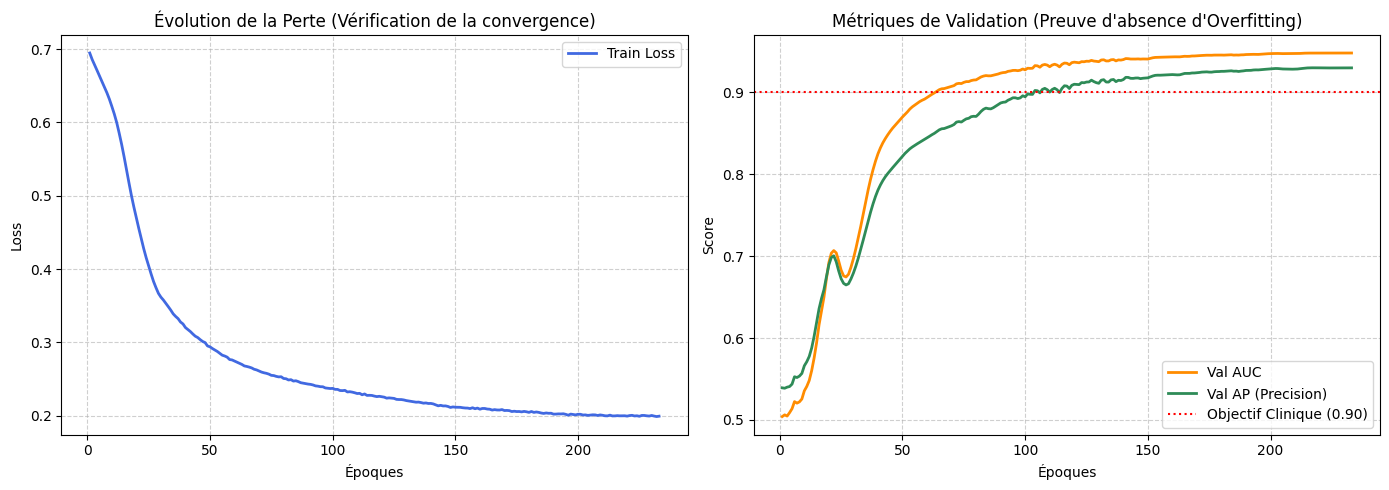

In [5]:
import matplotlib.pyplot as plt
import networkx as nx

#  1. AFFICHAGE DES COURBES D'APPRENTISSAGE 
epochs_range = range(1, len(history["train_loss"]) + 1)

plt.figure(figsize=(14, 5))

# Courbe de la perte (Loss)
plt.subplot(1, 2, 1)
plt.plot(epochs_range, history["train_loss"], label="Train Loss", color="royalblue", lw=2)
plt.title("Évolution de la Perte (Vérification de la convergence)", fontsize=12)
plt.xlabel("Époques")
plt.ylabel("Loss")
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend()

# Courbe des métriques de Validation
plt.subplot(1, 2, 2)
plt.plot(epochs_range, history["val_auc"], label="Val AUC", color="darkorange", lw=2)
plt.plot(epochs_range, history["val_ap"], label="Val AP (Precision)", color="seagreen", lw=2)
plt.axhline(y=0.90, color="red", linestyle=":", label="Objectif Clinique (0.90)")
plt.title("Métriques de Validation (Preuve d'absence d'Overfitting)", fontsize=12)
plt.xlabel("Époques")
plt.ylabel("Score")
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend()

plt.tight_layout()
plt.show()


🎲 Échantillon Aléatoire extrait : 60 patients et 165 liens.


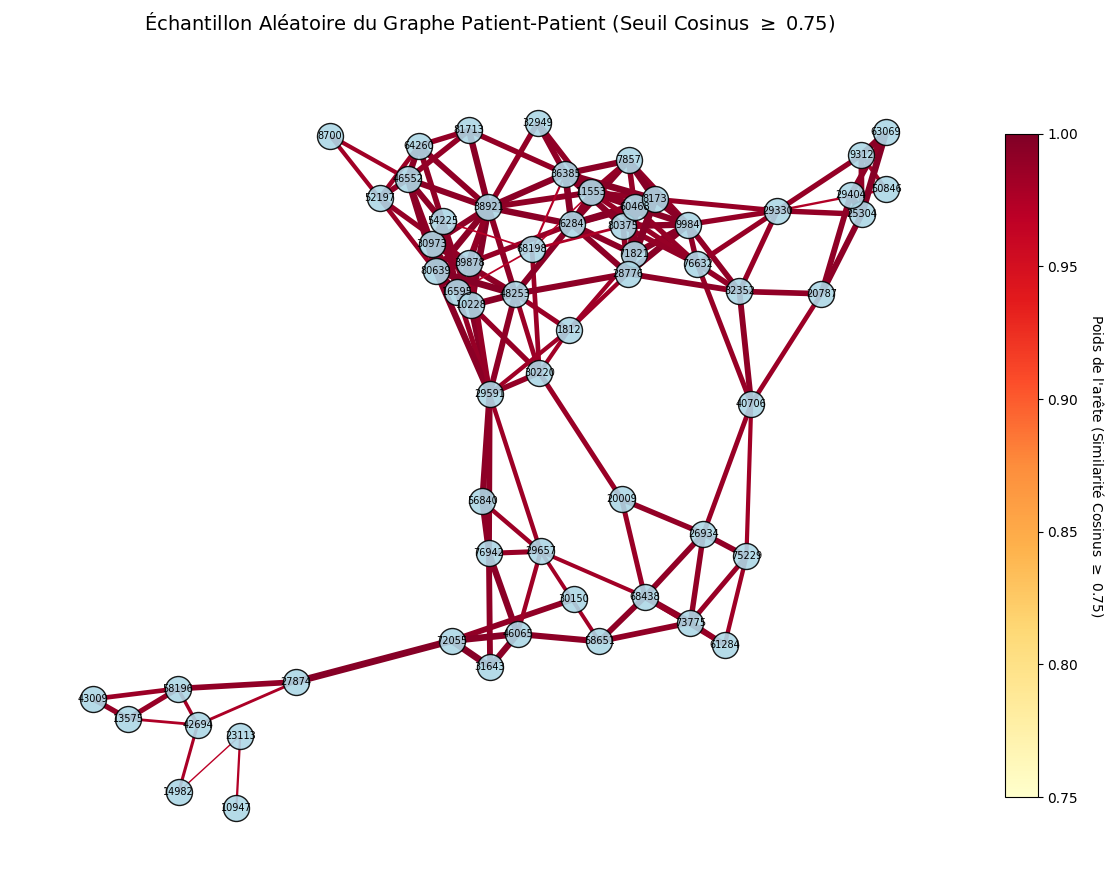

In [6]:
def plot_subgraph_with_weights_random(edge_index, edge_attr, num_nodes_to_viz=60, cosine_threshold=0.75):
    """
    Visualise un échantillon aléatoire mais interconnecté du graphe 
    via une méthode de marche aléatoire (Random Walk).
    """
    import networkx as nx
    import matplotlib.pyplot as plt
    import random
    
    # 1. Reconstruction du graphe NetworkX complet en arrière-plan
    G_all = nx.Graph()
    edges_np = edge_index.cpu().numpy()
    weights_np = edge_attr.cpu().numpy()
    
    for idx in range(edges_np.shape[1]):
        src = int(edges_np[0, idx])
        dst = int(edges_np[1, idx])
        G_all.add_edge(src, dst, weight=float(weights_np[idx]))
        
    # 2. Échantillonnage AU HASARD par Marche Aléatoire (Random Walk)
    all_nodes = list(G_all.nodes())
    selected_nodes = set()
    
    # Choisir un premier patient de départ complètement au hasard
    current_node = random.choice(all_nodes)
    selected_nodes.add(current_node)
    
    # On marche de voisin en voisin pour capturer une communauté locale au hasard
    attempts = 0
    while len(selected_nodes) < num_nodes_to_viz and attempts < 1000:
        neighbors = list(G_all.neighbors(current_node))
        if neighbors:
            current_node = random.choice(neighbors)
            selected_nodes.add(current_node)
        else:
            # Si on tombe dans un cul-de-sac, on saute sur un autre nœud au hasard
            current_node = random.choice(all_nodes)
            selected_nodes.add(current_node)
        attempts += 1

    # Création du sous-graphe induit par ces nœuds aléatoires
    G_sub = G_all.subgraph(list(selected_nodes))
    
    print(f"🎲 Échantillon Aléatoire extrait : {G_sub.number_of_nodes()} patients et {G_sub.number_of_edges()} liens.")

    # 3. Configuration du Rendu Graphique
    plt.figure(figsize=(12, 9), facecolor='white')
    ax = plt.gca()
    
    # Layout sans seed fixe pour changer la disposition visuelle à chaque exécution
    pos = nx.spring_layout(G_sub, k=1.5 / (G_sub.number_of_nodes()**0.5), iterations=50)
    
    edge_weights = [G_sub[u][v]['weight'] for u, v in G_sub.edges()]
    
    # Dessin des nœuds (Cercles bleus clairs)
    nx.draw_networkx_nodes(G_sub, pos, node_size=350, node_color='lightblue', edgecolors='black', alpha=0.9)
    nx.draw_networkx_labels(G_sub, pos, font_size=7, font_family='sans-serif')
    
    # Ajustement proportionnel de l'épaisseur des lignes
    if edge_weights:
        min_w, max_w = min(edge_weights), max(edge_weights)
        if max_w == min_w:
            widths = [2.0 for _ in edge_weights]
        else:
            widths = [1.0 + 4.0 * (w - min_w) / (max_w - min_w) for w in edge_weights]
    else:
        widths = []
    
    # Dessin des arêtes avec la colormap Jaune -> Rouge
    edges_drawn = nx.draw_networkx_edges(
        G_sub, pos, 
        width=widths,
        edge_color=edge_weights, 
        edge_cmap=plt.cm.YlOrRd,
        edge_vmin=cosine_threshold, edge_vmax=1.0
    )
    
    # 4. Colorbar et Titre
    cbar = plt.colorbar(edges_drawn, ax=ax, pad=0.03, shrink=0.8)
    cbar.set_label(r"Poids de l'arête (Similarité Cosinus $\geq$ " + f"{cosine_threshold:.2f})", rotation=270, labelpad=20)
    
    plt.title(r"Échantillon Aléatoire du Graphe Patient-Patient (Seuil Cosinus $\geq$ " + f"{cosine_threshold})", fontsize=14, pad=15)
    plt.axis('off')
    plt.tight_layout()
    
    # Sauvegarde de l'image propre
    #plt.savefig("echantillon_graphe_random.png", dpi=300, bbox_inches='tight')
    plt.show()

#  EXÉCUTION DE LA CELLULE 
COSINE_THRESHOLD = 0.75
plot_subgraph_with_weights_random(edge_index, edge_attr.squeeze(), num_nodes_to_viz=60, cosine_threshold=COSINE_THRESHOLD)

In [7]:
#  EXTRACTION ET SAUVEGARDE DES EMBEDDINGS PATIENTS ÉPURÉS (DIM 128) 

model.eval()
with torch.no_grad():
    # 1. Extraction des embeddings de tous les nœuds (Dimension: N x 128)
    z_nodes = model(data.x, data.edge_index, data.edge_attr).cpu().numpy()

print(f"Structure de la matrice de nœuds globale : {z_nodes.shape}") # Doit donner (total_patients, 128)

# 2. Séparation rigoureuse selon les tailles exactes des splits de la Phase 1
len_train = len(emb_train)
len_val   = len(emb_val)

d_graph_train = z_nodes[:len_train]
d_graph_val   = z_nodes[len_train : len_train + len_val]
d_graph_test  = z_nodes[len_train + len_val:]

# 3. Vérification des dimensions avant sauvegarde
print("\n=== VÉRIFICATION DES FEATURES DU GRAPHE AVANT EXPORT ===")
print(f" ──> d_graph_train.npy : {d_graph_train.shape}") # Doit être (72475, 128)
print(f" ──> d_graph_val.npy   : {d_graph_val.shape}")   # Doit être (4626, 128)
print(f" ──> d_graph_test.npy  : {d_graph_test.shape}")  # Doit être (5442, 128)

# 4. Sauvegarde physique des fichiers épurés
np.save("d_graph_train.npy", d_graph_train)
np.save("d_graph_val.npy", d_graph_val)
np.save("d_graph_test.npy", d_graph_test)

print("\n Fichiers d'embeddings épurés (128) sauvegardés avec succès ! Prêts pour la Phase 4.")

Structure de la matrice de nœuds globale : (82543, 128)

=== VÉRIFICATION DES FEATURES DU GRAPHE AVANT EXPORT ===
 ──> d_graph_train.npy : (72475, 128)
 ──> d_graph_val.npy   : (4626, 128)
 ──> d_graph_test.npy  : (5442, 128)

 Fichiers d'embeddings épurés (128) sauvegardés avec succès ! Prêts pour la Phase 4.
